In [4]:
import pickle

class RealTimeRecommender:
    def __init__(self, similarity_map_path):
        """Завантажує словник 1 раз при старті сервера"""
        print(f"Завантаження моделі з {similarity_map_path}...")
        with open(similarity_map_path, 'rb') as f:
            self.sim_map = pickle.load(f)
            
        # Зберігаємо список усіх існуючих аніме в базі для швидкої ініціалізації
        self.all_anime_ids = set(self.sim_map.keys())
        print(f"✅ Готово! В базі {len(self.all_anime_ids)} аніме.")

    def get_recommendations(self, user_profile, top_k=10):
        """
        user_profile: dict, наприклад {123: 1.0, 456: -1.0} (де 123 і 456 - це anime_id)
        top_k: int, скільки рекомендацій повернути
        """
        # 1. Створюємо словник кандидатів, де ВСІ аніме мають бал 0.0 з самого початку
        candidate_scores = {aid: 0.0 for aid in self.all_anime_ids}
        
        # 2. Розрахунок балів (Dynamic Scoring)
        for rated_anime, user_weight in user_profile.items():
            
            # Якщо оціненого аніме немає в нашій базі зв'язків — просто ігноруємо
            if rated_anime not in self.sim_map:
                continue
                
            # Поширюємо вплив
            for similar_anime, sim_score in self.sim_map[rated_anime].items():
                if similar_anime in candidate_scores:
                    candidate_scores[similar_anime] += user_weight * sim_score

        # 3. Відсіювання (Видаляємо ті аніме, які юзер вже оцінив)
        for rated_anime in user_profile.keys():
            # Безпечне видалення (якщо раптом його там не було)
            candidate_scores.pop(rated_anime, None)

        # 4. Сортування та видача
        sorted_candidates = sorted(candidate_scores.items(), key=lambda item: item[1], reverse=True)
        
        return sorted_candidates[:top_k]

In [12]:
import os

# --- ІНІЦІАЛІЗАЦІЯ (Робиться 1 раз при старті додатку) ---
# Вказуємо шлях до вашого реального оптимізованого файлу
output_dir = os.path.join('..', 'data')
map_path = os.path.join(output_dir, 'svd_similarity_map_optimized.pkl')

# Створюємо ЄДИНИЙ глобальний об'єкт рекомендатора
recommender = RealTimeRecommender(map_path)


# --- ТЕСТУВАННЯ (Імітація API запитів від різних користувачів) ---

# Для тесту візьмемо якісь реальні MAL_ID (наприклад, 20 - Naruto, 1535 - Death Note)
# Замініть ці ID на ті, які точно є у вашому датасеті для перевірки

print("\n--- Запит від Користувача 1 (Фанатик Наруто) ---")
user1_profile = {20: 1.0, 1735: 1.0} # 20 = Naruto, 1735 = Naruto Shippuden
user1_recs = recommender.get_recommendations(user1_profile, top_k=5)

print("Рекомендуємо Користувачу 1:")
for rank, (anime_id, score) in enumerate(user1_recs, 1):
    print(f"{rank}. Anime ID: {anime_id} (Бал: {score:.4f})")


print("\n--- Запит від Користувача 2 (Хейтер) ---")
# Оцінив одне погано, інше добре
user2_profile = {1535: -1.0, 5114: 1.0} # 1535 = Death Note, 5114 = FMA: Brotherhood
user2_recs = recommender.get_recommendations(user2_profile, top_k=5)

print("Рекомендуємо Користувачу 2:")
for rank, (anime_id, score) in enumerate(user2_recs, 1):
    print(f"{rank}. Anime ID: {anime_id} (Бал: {score:.4f})")

Завантаження моделі з ..\data\svd_similarity_map_optimized.pkl...
✅ Готово! В базі 15424 аніме.

--- Запит від Користувача 1 (Фанатик Наруто) ---
Рекомендуємо Користувачу 1:
1. Anime ID: 269 (Бал: 1.0506)
2. Anime ID: 8246 (Бал: 0.8828)
3. Anime ID: 16870 (Бал: 0.8493)
4. Anime ID: 6325 (Бал: 0.8475)
5. Anime ID: 10589 (Бал: 0.8392)

--- Запит від Користувача 2 (Хейтер) ---
Рекомендуємо Користувачу 2:
1. Anime ID: 2001 (Бал: 0.4310)
2. Anime ID: 2418 (Бал: 0.3936)
3. Anime ID: 37510 (Бал: 0.3884)
4. Anime ID: 19 (Бал: 0.3865)
5. Anime ID: 36766 (Бал: 0.3795)


In [15]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

# 1. Завантаження даних
# Припускаємо, що train_final.parquet та test_sampled.parquet вже є у вашій папці
print("Завантаження даних...")
output_dir = os.path.join('..', 'data')
test_sampled = pd.read_parquet(os.path.join(output_dir, 'test_sampled.parquet'))
output_dir = os.path.join(output_dir, 'processed')
train_final = pd.read_parquet(os.path.join(output_dir, 'train_final.parquet'))


unique_users = test_sampled['user_id'].unique()
train_sampled = train_final[train_final['user_id'].isin(unique_users)].copy()

print(f"Відібрано {len(unique_users)} користувачів для тесту.")

# 2. Функції конвертації та метрик
def rating_to_weight(rating):
    """Перетворює 10-бальну оцінку на вагу для алгоритму"""
    if rating >= 8: return 1.0
    #elif rating <= 4: return -1.0
    else: return -1.0

def calculate_ranking_metrics(true_items_ratings, predicted_ranked_items, k=10):
    relevant_items = {iid for iid, rating in true_items_ratings.items() if rating >= 8}
    if not relevant_items: return None 
        
    top_k_pred = predicted_ranked_items[:k]
    hits = len(set(top_k_pred).intersection(relevant_items))
    
    precision = hits / k
    recall = hits / len(relevant_items)
    
    mrr = 0.0
    for rank, item in enumerate(predicted_ranked_items):
        if item in relevant_items:
            mrr = 1.0 / (rank + 1)
            break
            
    y_true = [1 if item in relevant_items else 0 for item in predicted_ranked_items]
    y_scores = list(range(len(predicted_ranked_items), 0, -1)) 
    try: auc = roc_auc_score(y_true, y_scores)
    except: auc = np.nan
        
    return {'Precision@10': precision, 'Recall@10': recall, 'MRR': mrr, 'AUC': auc}

# 3. Головний цикл тестування
results_list = []
# recommender - це ваш об'єкт класу RealTimeRecommender, створений раніше

for user_id in tqdm(unique_users, desc="Тестування In-Memory моделі"):
    
    # Дані тесту (майбутнє)
    user_test = test_sampled[test_sampled['user_id'] == user_id]
    true_ratings = dict(zip(user_test['anime_id'], user_test['rating']))
    
    if not any(r >= 8 for r in true_ratings.values()):
        continue
        
    train_count = user_test['train_count'].iloc[0]
    
    # Дані тренування (історія)
    user_train = train_sampled[train_sampled['user_id'] == user_id]
    
    # Формуємо профіль користувача: {anime_id: weight}
    user_profile = {
        row['anime_id']: rating_to_weight(row['rating']) 
        for _, row in user_train.iterrows()
    }
    
    # Отримуємо рекомендації. 
    # Важливо: просимо видати ВСІ аніме (len(all_anime_ids)), щоб AUC порахувався коректно
    recs = recommender.get_recommendations(user_profile, top_k=len(recommender.all_anime_ids))
    
    # Витягуємо тільки ідентифікатори аніме по порядку спадання балу
    ranked_items = [aid for aid, score in recs]
    
    # Рахуємо метрики
    metrics = calculate_ranking_metrics(true_ratings, ranked_items, k=10)
    
    if metrics:
        metrics['user_id'] = user_id
        metrics['train_count'] = train_count
        results_list.append(metrics)

# Зберігаємо результати у DataFrame
rt_metrics_df = pd.DataFrame(results_list)
print("\n✅ Розрахунок завершено! Середні метрики:")
print(rt_metrics_df[['Precision@10', 'Recall@10', 'MRR', 'AUC']].mean())

Завантаження даних...
Відібрано 1590 користувачів для тесту.


Тестування In-Memory моделі: 100%|██████████| 1590/1590 [00:45<00:00, 34.86it/s]


✅ Розрахунок завершено! Середні метрики:
Precision@10    0.363453
Recall@10       0.075114
MRR             0.655556
AUC             0.711897
dtype: float64


Підготовка даних для In-Memory моделі...


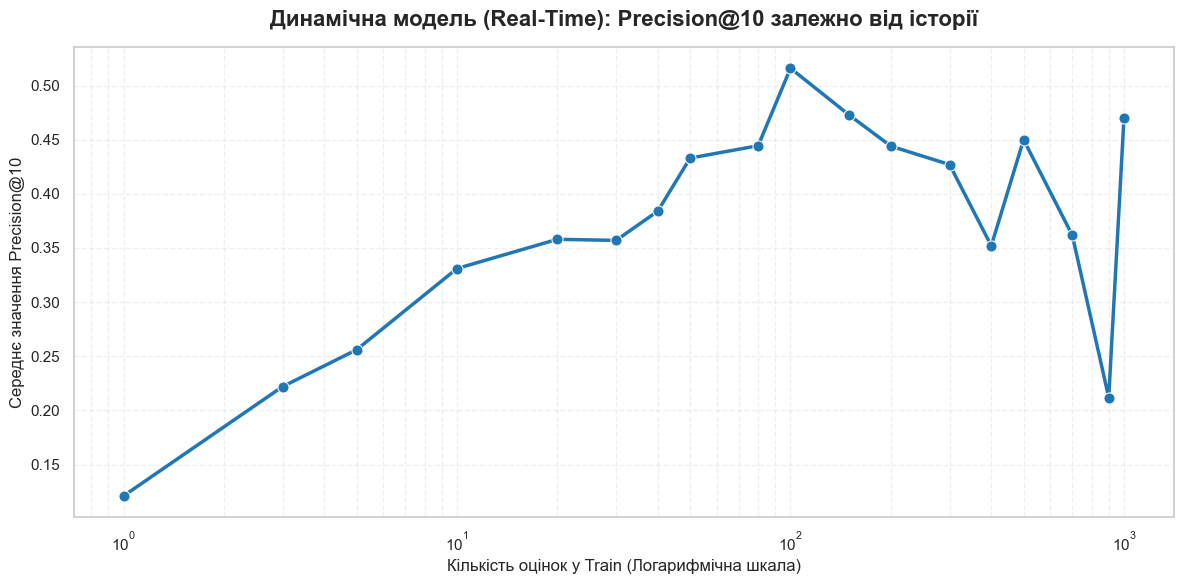

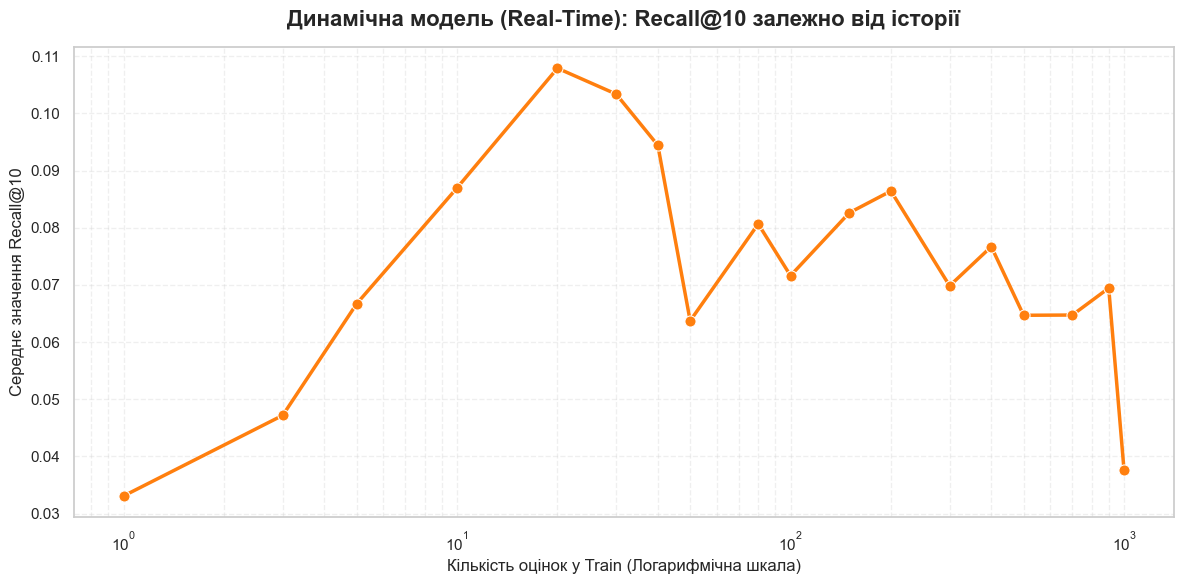

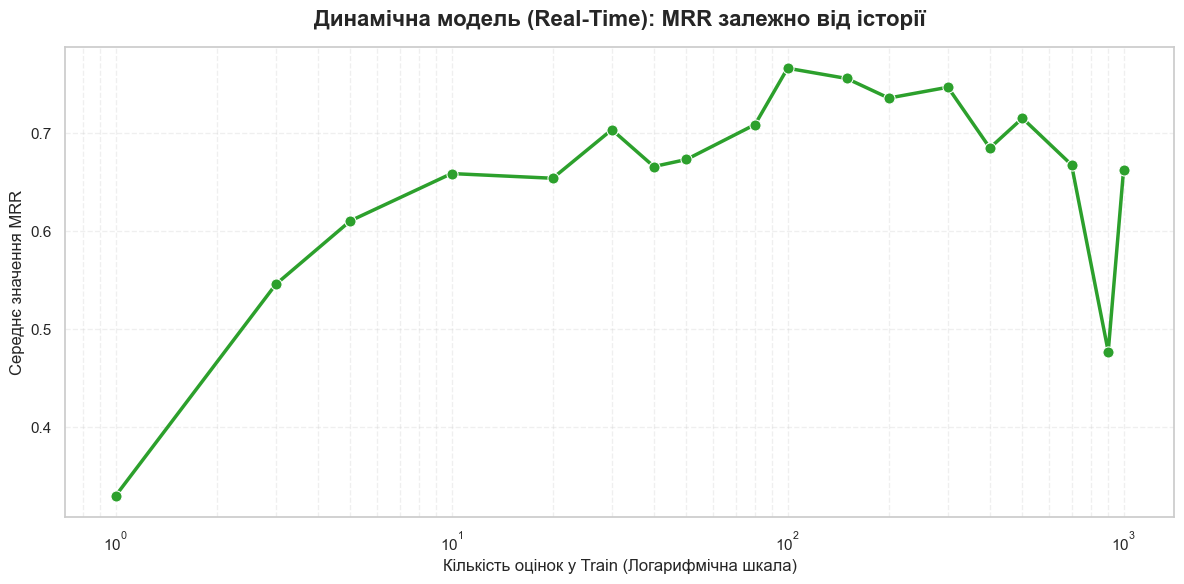

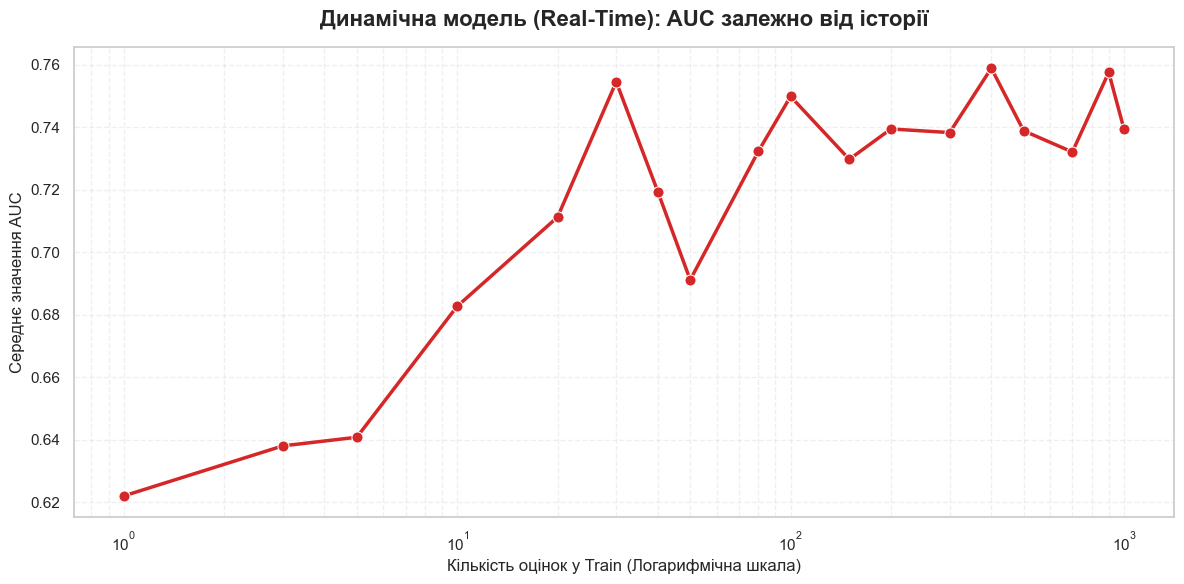

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Налаштування стилю
sns.set_theme(style="whitegrid")

print("Підготовка даних для In-Memory моделі...")

# Відбираємо наші референсні точки для осі X
ref_counts = [1, 3, 5, 10, 20, 30, 40, 50, 80, 100, 150, 200, 300, 400, 500, 700, 900, 1000]

# Фільтруємо датафрейм (передбачається, що rt_metrics_df у вас вже є в пам'яті)
df_filtered = rt_metrics_df[rt_metrics_df['train_count'].isin(ref_counts)].copy()

# Групуємо і знаходимо середнє значення кожної метрики для кожної точки
trend_data = df_filtered.groupby('train_count').mean().reset_index()

metrics_to_plot = ['Precision@10', 'Recall@10', 'MRR', 'AUC']
# Задаємо окремий колір для графіка кожної метрики
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

# Будуємо 4 окремі графіки
for i, metric in enumerate(metrics_to_plot):
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(
        data=trend_data, 
        x='train_count', 
        y=metric, 
        marker='o',       # Додаємо точки
        linewidth=2.5,
        color=colors[i],
        markersize=8
    )
    
    # Налаштування осей
    plt.xscale('log')
    plt.title(f'Динамічна модель (Real-Time): {metric} залежно від історії', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Кількість оцінок у Train (Логарифмічна шкала)', fontsize=12)
    plt.ylabel(f'Середнє значення {metric}', fontsize=12)
    
    plt.grid(True, which="both", alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80 + "\n")

In [17]:
import numpy as np

print("--- Генерація Active Learning Queue ---")

# Крок 1: Ініціалізація глобального словника
hub_scores = {aid: 0.0 for aid in recommender.all_anime_ids}

# Крок 2: Зважений підрахунок центральності (Weighted Degree Centrality)
for source_anime, neighbors in recommender.sim_map.items():
    # Ми беремо абсолютне значення (abs), адже якщо це SVD, 
    # сильний негативний зв'язок (антипод) — це теж потужний сигнал!
    total_weight = sum(abs(score) for score in neighbors.values())
    hub_scores[source_anime] += total_weight

# Крок 3 & 4: Сортування та формування масиву
sorted_hubs = sorted(hub_scores.items(), key=lambda item: item[1], reverse=True)

# Фінальна черга (просто список ID)
active_learning_queue = [aid for aid, score in sorted_hubs]

print(f"✅ Черга сформована! Всього вузлів: {len(active_learning_queue)}")
print("Топ-5 головних хабів каталогу (ID):")
for rank, (aid, score) in enumerate(sorted_hubs[:5], 1):
    print(f"{rank}. Anime ID: {aid} (Вплив: {score:.2f})")
    
# Опціонально: збереження черги
# import pickle
# with open('active_learning_queue.pkl', 'wb') as f:
#     pickle.dump(active_learning_queue, f)

--- Генерація Active Learning Queue ---
✅ Черга сформована! Всього вузлів: 15424
Топ-5 головних хабів каталогу (ID):
1. Anime ID: 30404 (Вплив: 1019.83)
2. Anime ID: 32830 (Вплив: 997.82)
3. Anime ID: 37065 (Вплив: 991.81)
4. Anime ID: 33273 (Вплив: 987.72)
5. Anime ID: 34628 (Вплив: 983.60)


In [22]:
import pandas as pd
import os

print("Завантаження метаданих аніме...")

# 1. Завантажуємо anime_clean (переконайтеся, що output_dir визначено)
anime_clean = pd.read_parquet(os.path.join(output_dir, "anime_clean.parquet"))

# 2. Беремо Топ-10 ID з нашої згенерованої черги
top_10_hub_ids = active_learning_queue[:10]

# 3. Відфільтровуємо датафрейм
top_10_anime = anime_clean[anime_clean['MAL_ID'].isin(top_10_hub_ids)].copy()

# 4. ТРЮК PANDAS: Зберігаємо правильний порядок сортування (як у нашому списку)
top_10_anime['MAL_ID'] = pd.Categorical(top_10_anime['MAL_ID'], categories=top_10_hub_ids, ordered=True)
top_10_anime = top_10_anime.sort_values('MAL_ID')

# 5. Обираємо найважливіші колонки для відображення
# (Якщо у вашому anime_clean колонки називаються інакше, наприклад Name замість title, змініть їх тут)
columns_to_show = ['MAL_ID', 'Name', 'Genres', 'Type', 'Score', 'Members']
existing_cols = [col for col in columns_to_show if col in top_10_anime.columns]

print(f"\n--- ТОП-10 АНІМЕ-ХАБІВ (Active Learning) ---")
# Якщо ви в Jupyter/Colab, display() зробить красиву HTML-табличку
display(top_10_anime[existing_cols].reset_index(drop=True))

Завантаження метаданих аніме...

--- ТОП-10 АНІМЕ-ХАБІВ (Active Learning) ---


,MAL_ID,Name,Genres,Type,Score,Members
0,30404,Taku Boda,Dementia,Movie,5.07,311
1,32830,Chou Shounen Tanteidan Neo,Mystery,TV,5.25,2267
2,37065,123,"Kids, Music",Music,4.84,307
3,33273,Bouningen Weekend,Slice of Life,ONA,5.36,268
4,34628,Taka no Tsume x Hello Kitty ga Masaka no Collab!,Comedy,ONA,NaN,195
5,17825,Ikenai Boy: Ikasu Maruhi Hand Power,"Comedy, Hentai",OVA,NaN,383
6,30427,Mr. Empty,Music,Music,4.79,297
7,35407,Rhythm,Dementia,Movie,4.76,341
8,29861,Channel 5.5 3rd Season Prologue,Comedy,ONA,NaN,405
9,31259,Thunder,Dementia,Movie,5.27,550


In [21]:
anime_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 17562 entries, 0 to 17561
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   MAL_ID                  17562 non-null  int64  
 1   Name                    17562 non-null  str    
 2   Score                   12421 non-null  float64
 3   Genres                  17499 non-null  str    
 4   English name            6997 non-null   str    
 5   Japanese name           17514 non-null  str    
 6   Type                    17525 non-null  str    
 7   Episodes                17046 non-null  float64
 8   Aired                   17253 non-null  str    
 9   Premiered               4745 non-null   str    
 10  Producers               9768 non-null   str    
 11  Licensors               3946 non-null   str    
 12  Studios                 10483 non-null  str    
 13  Source                  13995 non-null  str    
 14  Duration                17007 non-null  str    
 

In [23]:
import numpy as np

print("--- Генерація РОЗУМНОЇ Active Learning Queue ---")

# 1. Створюємо словник популярності з anime_clean
popularity_dict = dict(zip(anime_clean['MAL_ID'], anime_clean['Members']))

# Мінімальний поріг популярності: питаємо лише про тайтли, де є хоча б 100k+ учасників
MIN_MEMBERS = 100000 

hub_scores = {}

# 2. Розрахунок хабів
for source_anime, neighbors in recommender.sim_map.items():
    members = popularity_dict.get(source_anime, 0)
    
    # Відкидаємо "Кластер невідомого"
    if members < MIN_MEMBERS:
        continue
        
    # Рахуємо зв'язність
    total_weight = sum(abs(score) for score in neighbors.values())
    
    # ФОРМУЛА: Множимо зв'язність на логарифм популярності.
    # Логарифм потрібен, щоб популярність не перекреслила саму зв'язність.
    hub_scores[source_anime] = total_weight * np.log10(members)

# 3. Сортування та формування масиву
sorted_hubs = sorted(hub_scores.items(), key=lambda item: item[1], reverse=True)

active_learning_queue = [aid for aid, score in sorted_hubs]

print(f"✅ Нова черга сформована! Всього валідних вузлів: {len(active_learning_queue)}")

# --- Вивід нових Топ-10 ---
top_10_hub_ids = active_learning_queue[:10]
top_10_anime = anime_clean[anime_clean['MAL_ID'].isin(top_10_hub_ids)].copy()
top_10_anime['MAL_ID'] = pd.Categorical(top_10_anime['MAL_ID'], categories=top_10_hub_ids, ordered=True)
top_10_anime = top_10_anime.sort_values('MAL_ID')

columns_to_show = ['MAL_ID', 'Name', 'Genres', 'Type', 'Score', 'Members']
existing_cols = [col for col in columns_to_show if col in top_10_anime.columns]

print(f"\n--- СПРАВЖНІ ТОП-10 АНІМЕ-ХАБІВ ---")
display(top_10_anime[existing_cols].reset_index(drop=True))

--- Генерація РОЗУМНОЇ Active Learning Queue ---
✅ Нова черга сформована! Всього валідних вузлів: 1369

--- СПРАВЖНІ ТОП-10 АНІМЕ-ХАБІВ ---


,MAL_ID,Name,Genres,Type,Score,Members
0,21033,Seikoku no Dragonar,"Comedy, Ecchi, Fantasy, School",TV,6.52,170220
1,37744,Isekai Cheat Magician,"Action, Adventure, Fantasy",TV,5.38,191481
2,24873,Juuou Mujin no Fafnir,"Fantasy, Harem, Romance, School",TV,6.25,126029
3,6324,Omamori Himari,"Action, Harem, Comedy, Demons, Supernatural, R...",TV,6.93,201739
4,31338,Hundred,"Action, Sci-Fi, Harem, Romance, Ecchi, Mecha, ...",TV,6.37,272970
5,25283,Kuusen Madoushi Kouhosei no Kyoukan,"Action, Drama, Fantasy, Magic, School",TV,6.40,198059
6,25429,Isuca,"Action, Comedy, Ecchi, Romance, School, Seinen...",TV,6.03,122521
7,30749,Saijaku Muhai no Bahamut,"Action, Harem, Supernatural, Romance, Ecchi, F...",TV,6.62,279062
8,22877,Seireitsukai no Blade Dance,"Action, Harem, Comedy, Supernatural, Romance, ...",TV,6.82,283537
9,37446,Hyakuren no Haou to Seiyaku no Valkyria,"Fantasy, Harem",TV,5.75,127112


In [24]:
import networkx as nx
import pandas as pd

print("--- Крок 1: Побудова графа та Кластеризація (Метод Лувена) ---")

# 1. Створюємо порожній неорієнтований граф
G = nx.Graph()

# 2. Наповнюємо граф ребрами з вашого словника
for source, neighbors in recommender.sim_map.items():
    for target, weight in neighbors.items():
        # Для кластеризації спільнот беремо тільки позитивні зв'язки (схожість)
        # Якщо використовуєте SVD-словник, негативні зв'язки означають "антиподи", їх ми для кластерів ігноруємо
        if weight > 0: 
            G.add_edge(source, target, weight=weight)

# 3. Запускаємо Метод Лувена (вбудований у сучасний NetworkX)
# Він поверне список множин (sets), де кожна множина - це кластер (спільнота)
communities = list(nx.community.louvain_communities(G, weight='weight'))

print(f"✅ Граф успішно розбито на {len(communities)} унікальних кластерів!")

print("\n--- Крок 2: Сортування та підготовка Round-Robin черги ---")

# Створюємо словник популярності (Показник Popularity: 1 - найпопулярніше, чим більше, тим гірше)
# Переконайтеся, що колонка називається 'popularity'. Якщо її немає, можна використати 'members', але тоді сортувати треба у зворотному порядку (reverse=True)
pop_dict = dict(zip(anime_clean['MAL_ID'], anime_clean['Popularity']))

# 1. Готуємо списки для кожного кластера
clusters_sorted = []

for comm in communities:
    # Залишаємо тільки ті аніме, про які є інфа в anime_clean
    valid_nodes = [node for node in comm if node in pop_dict]
    
    # Сортуємо аніме всередині кластера ЗА ЗРОСТАННЯМ Popularity (1, 2, 3...)
    sorted_nodes = sorted(valid_nodes, key=lambda x: pop_dict[x])
    
    if sorted_nodes:
        clusters_sorted.append(sorted_nodes)

# 2. Сортуємо самі кластери за кількістю аніме в них (від найбільшого до найменшого)
clusters_sorted.sort(key=len, reverse=True)

print(f"Розміри Топ-5 найбільших кластерів: {[len(c) for c in clusters_sorted[:5]]}")

print("\n--- Крок 3: Формування глобальної черги (Round-Robin) ---")

active_learning_queue = []

# Поки хоча б в одному кластері є елементи - продовжуємо цикл
while any(clusters_sorted):
    for cluster in clusters_sorted:
        if cluster: # Якщо кластер ще не порожній
            # Забираємо ПЕРШИЙ елемент (найпопулярніше аніме цього кластера) і додаємо в чергу
            active_learning_queue.append(cluster.pop(0))

print(f"✅ Ідеальна черга сформована! Всього вузлів: {len(active_learning_queue)}")

# --- Вивід перших 10 аніме з черги для перевірки ---
top_10_hub_ids = active_learning_queue[:10]
top_10_anime = anime_clean[anime_clean['MAL_ID'].isin(top_10_hub_ids)].copy()

# Зберігаємо правильний порядок
top_10_anime['MAL_ID'] = pd.Categorical(top_10_anime['MAL_ID'], categories=top_10_hub_ids, ordered=True)
top_10_anime = top_10_anime.sort_values('MAL_ID')

# Показуємо результат
columns_to_show = ['MAL_ID', 'Name', 'Score', 'Genres', 'Popularity', 'Members']
existing_cols = [col for col in columns_to_show if col in top_10_anime.columns]

print(f"\n--- СПРАВЖНІ ТОП-10 ДЛЯ ОНБОРДИНГУ (З різних кластерів) ---")
display(top_10_anime[existing_cols].reset_index(drop=True))

--- Крок 1: Побудова графа та Кластеризація (Метод Лувена) ---
✅ Граф успішно розбито на 5 унікальних кластерів!

--- Крок 2: Сортування та підготовка Round-Robin черги ---
Розміри Топ-5 найбільших кластерів: [8284, 3479, 1867, 1387, 407]

--- Крок 3: Формування глобальної черги (Round-Robin) ---
✅ Ідеальна черга сформована! Всього вузлів: 15424

--- СПРАВЖНІ ТОП-10 ДЛЯ ОНБОРДИНГУ (З різних кластерів) ---


,MAL_ID,Name,Score,Genres,Popularity,Members
0,1535,Death Note,8.63,"Mystery, Police, Psychological, Supernatural, ...",1,2589552
1,47,Akira,8.17,"Action, Military, Sci-Fi, Adventure, Horror, S...",197,566538
2,21039,Gatchaman Crowds Insight,7.30,"Adventure, Sci-Fi",1923,63861
3,1293,Urusei Yatsura,7.69,"Action, Sci-Fi, Adventure, Comedy, Drama, Romance",2056,57537
4,20583,Haikyuu!!,8.53,"Comedy, Sports, Drama, School, Shounen",50,1185274
5,16498,Shingeki no Kyojin,8.48,"Action, Military, Mystery, Super Power, Drama,...",2,2531397
6,339,Serial Experiments Lain,8.03,"Dementia, Drama, Mystery, Psychological, Sci-F...",255,480696
7,35015,Ani ni Tsukeru Kusuri wa Nai!,7.46,"Slice of Life, Comedy, School",1990,60586
8,368,Bible Black,6.65,Hentai,2132,54714
9,28891,Haikyuu!! Second Season,8.73,"Comedy, Sports, Drama, School, Shounen",94,874150
